In [5]:
# 1. 必要なパッケージのリスト
required_packages <- c(
  "tidyverse",   # データ処理・可視化
  "ranger",      # 高速ランダムフォレスト
  "xgboost",     # 勾配ブースティング
  "nnet",        # ニューラルネットワーク
  "iml",         # PFI, PD, ALE, ICE, Interaction(H-stat)
  "fastshap",    # 高速SHAP計算
  "shapviz",     # SHAP可視化 (Summary, Dependence)
  "gridExtra",   # レイアウト調整
  "ggplot2",     # グラフカスタマイズ
  "dplyr",       # データ操作
  "midr",        # MID交互作用解析
  "DALEX",       # モデル比較・説明
  "DALEXtra"     # tidymodels連携用
)

  
# 2. 未インストールのものを特定してインストール
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) {
  cat("以下のパッケージをインストールします:", new_packages, "\n")
  install.packages(new_packages, repos = "https://cran.ism.ac.jp/")
} else {
  cat("すべての必要なパッケージは既にインストールされています。\n")
}

# 3. ライブラリの読み込み
library(tidyverse)
library(ranger)
library(xgboost)
library(nnet)
library(iml)
library(fastshap)
library(shapviz)
library(grid)
library(gridExtra)
library(midr)
library(DALEX)
library(DALEXtra)



cat("セットアップが完了しました。解析を開始できます。")

すべての必要なパッケージは既にインストールされています。



次のパッケージを付け加えます: ‘fastshap’


以下のオブジェクトは ‘package:DALEX’ からマスクされています:

    explain, titanic


以下のオブジェクトは ‘package:dplyr’ からマスクされています:

    explain




セットアップが完了しました。解析を開始できます。

Learning models...


Warning message in throw_err_or_depr_msg("Parameter(s) have been removed from this function: ", :
“Parameter(s) have been removed from this function: params. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Passed unrecognized parameters: ", paste(head(names_unrecognized), :
“Passed unrecognized parameters: verbose. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'data' has been renamed to 'x'. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'label' has been renamed to 'y'. This warning will become an error in a future version.”


Processing: Linear_Regression 
Processing: Random_Forest 
Processing: XGBoost 
Processing: Neural_Network 


agg_record_238968156 
                   2

Done! Report saved as Wine_XAI_IML_Report_v2.pdf


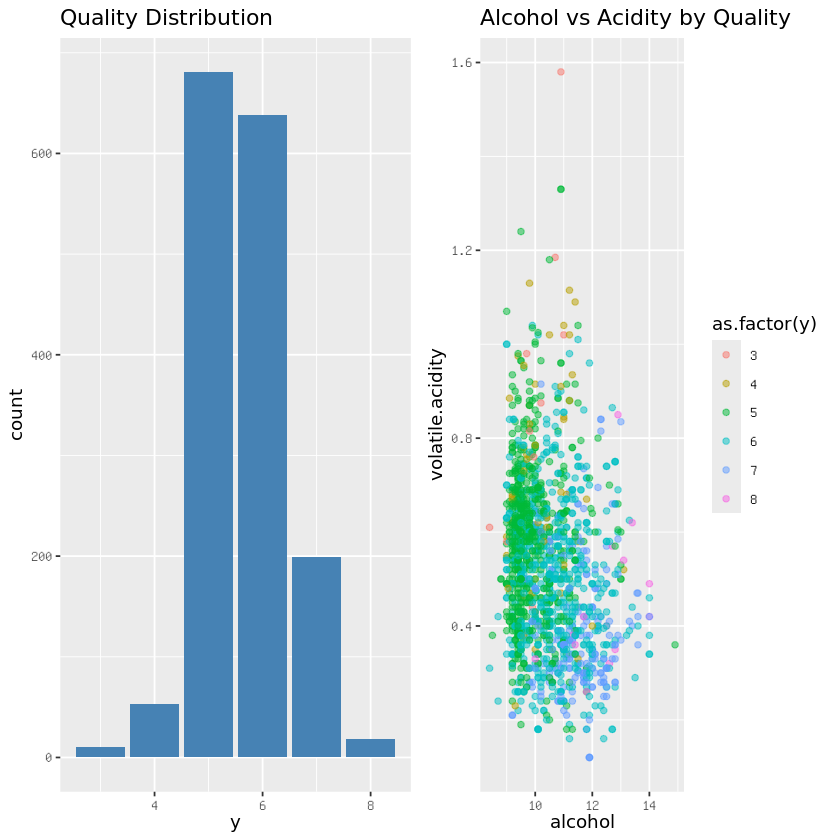

In [9]:
# ==========================================
# 1. パッケージのセットアップ
# ==========================================
required_packages <- c(
  "tidyverse", "ranger", "xgboost", "iml", 
  "gridExtra", "midr", "DALEX", "DALEXtra", "nnet", "grid"
)
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages, repos = "https://cran.ism.ac.jp/")

library(tidyverse)
library(ranger)
library(xgboost)
library(iml)
library(gridExtra)
library(midr)
library(DALEX)
library(DALEXtra)
library(nnet)
library(grid)

# ==========================================
# 2. データの読み込み
# ==========================================
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine <- read.csv(url, sep = ";")
colnames(wine)[ncol(wine)] <- "y"

x <- wine %>% dplyr::select(-y)
y <- wine$y

# 分布の表示
p_dist1 <- ggplot(wine, aes(x = y)) + geom_bar(fill = "steelblue") + labs(title = "Quality Distribution")
p_dist2 <- ggplot(wine, aes(x = alcohol, y = volatile.acidity, color = as.factor(y))) + 
  geom_point(alpha = 0.5) + labs(title = "Alcohol vs Acidity by Quality")
grid.arrange(p_dist1, p_dist2, ncol = 2)

# ==========================================
# 3. モデルの学習
# ==========================================
cat("Learning models...\n")
x_scaled <- as.data.frame(scale(x))
wine_scaled <- cbind(x_scaled, y = y)

model_list <- list(
  "Linear_Regression" = lm(y ~ ., data = wine),
  "Random_Forest"    = ranger(y ~ ., data = wine, importance = "permutation"),
  "XGBoost"          = xgboost(data = as.matrix(x), label = y, nrounds = 50, verbose = 0, params = list(objective = "reg:squarederror")),
  "Neural_Network"   = nnet(y ~ ., data = wine_scaled, size = 5, linout = TRUE, trace = FALSE, maxit = 500)
)

# ==========================================
# 4. iml による一括解析ループ
# ==========================================
pdf("Wine_XAI_IML_Report_v2.pdf", width = 18, height = 14)

for (name in names(model_list)) {
  cat("Processing:", name, "\n")
  mod <- model_list[[name]]
  
  p_fun <- function(object, newdata) {
    newdata_df <- as.data.frame(newdata)
    if (inherits(object, "ranger")) return(predict(object, data = newdata_df)$predictions)
    if (inherits(object, "xgb.Booster")) return(predict(object, as.matrix(newdata_df)))
    if (inherits(object, "nnet")) return(as.numeric(predict(object, newdata_df)))
    return(as.numeric(predict(object, newdata_df)))
  }
  
  current_x <- if(name == "Neural_Network") x_scaled else x
  current_y <- y
  current_data <- if(name == "Neural_Network") wine_scaled else wine

  predictor <- Predictor$new(mod, data = current_x, y = current_y, predict.fun = p_fun)

  # PFI & Interaction
  p1 <- plot(FeatureImp$new(predictor, loss = "rmse")) + ggtitle("PFI (Importance)")
  p5 <- plot(Interaction$new(predictor, feature = "alcohol")) + ggtitle("Interaction (H-stat for Alcohol)")

  # PD & ICE / ALE
  p2 <- plot(FeatureEffect$new(predictor, feature = "alcohol", method = "pdp+ice")) + ggtitle("PD & ICE (Alcohol)")
  p3 <- plot(FeatureEffect$new(predictor, feature = "alcohol", method = "ale")) + ggtitle("ALE (Alcohol)")
  
  # --- Grouped PDP の修正 ---
  # データを分割してそれぞれのPDPを計算し、手動で結合することでエラーを回避
  v_med <- median(current_x$volatile.acidity)
  idx_high <- current_x$volatile.acidity > v_med
  
  pdp_high <- FeatureEffect$new(Predictor$new(mod, data = current_x[idx_high, ], predict.fun = p_fun), 
                                feature = "alcohol", method = "pdp")$results
  pdp_low  <- FeatureEffect$new(Predictor$new(mod, data = current_x[!idx_high, ], predict.fun = p_fun), 
                                feature = "alcohol", method = "pdp")$results
  
  pdp_combined <- rbind(mutate(pdp_high, group = "High_Acid"), 
                        mutate(pdp_low, group = "Low_Acid"))
  
  p4 <- ggplot(pdp_combined, aes(x = alcohol, y = .value, color = group)) + 
    geom_line(linewidth = 1.5) + theme_minimal() + labs(title = "Grouped PDP (by Acidity)")

  # Shapley
  shapley <- Shapley$new(predictor, x.interest = current_x[1, ])
  p6 <- plot(shapley) + ggtitle("SHAP (Shapley) for Sample #1")

  # MID
  tryCatch({
    res_mid <- midr::interpret(y ~ (.)^2, data = current_data, model = mod, predict_function = p_fun)
    p9 <- ggmid(mid.importance(res_mid), type = "heatmap", theme = "Oslo") + 
          labs(title = "MID Heatmap", subtitle = paste("UR:", round(res_mid$ratio, 4)))
  }, error = function(e) { p9 <<- ggplot() + labs(title = "MID Error") })

  # 出力
  grid.arrange(p1, p5, p6, p9, ncol = 2, top = textGrob(paste("Model:", name), gp=gpar(fontSize=22, font=2)))
  grid.arrange(p2, p3, p4, ncol = 2, top = textGrob(paste(name, ": Alcohol Effects"), gp=gpar(fontSize=22, font=2)))
}

dev.off()
cat("Done! Report saved as Wine_XAI_IML_Report_v2.pdf\n")

In [1]:
# ==========================================
# 1. セットアップ（ライブラリ読み込み）
# ==========================================
library(tidyverse)
library(ranger)
library(xgboost)
library(iml)
library(gridExtra)
library(midr)
library(nnet)
library(grid)

# ==========================================
# 2. データの読み込みと準備
# ==========================================
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine <- read.csv(url, sep = ";")
colnames(wine)[ncol(wine)] <- "y"

x <- wine %>% dplyr::select(-y)
y <- wine$y

# スケーリング済みデータ（NN用）
x_scaled <- as.data.frame(scale(x))
wine_scaled <- cbind(x_scaled, y = y)

# モデルの学習
cat("Modeling...\n")
model_list <- list(
  "Linear_Regression" = lm(y ~ ., data = wine),
  "Random_Forest"    = ranger(y ~ ., data = wine, importance = "permutation"),
  "XGBoost"          = xgboost(data = as.matrix(x), label = y, nrounds = 50, verbose = 0, params = list(objective = "reg:squarederror")),
  "Neural_Network"   = nnet(y ~ ., data = wine_scaled, size = 5, linout = TRUE, trace = FALSE, maxit = 500)
)

# ==========================================
# 3. PDF出力開始（ここからPDFに書き込まれます）
# ==========================================
pdf("Wine_Full_XAI_Report.pdf", width = 18, height = 14)

# --- [Page 1] データの分布 ---
cat("Plotting distributions...\n")
p_dist1 <- ggplot(wine, aes(x = y)) + geom_bar(fill = "steelblue") + 
  theme_minimal() + labs(title = "Target Distribution (Wine Quality)")

p_dist2 <- ggplot(wine, aes(x = alcohol, y = volatile.acidity, color = as.factor(y))) + 
  geom_point(alpha = 0.5) + scale_color_viridis_d() +
  theme_minimal() + labs(title = "Feature Interaction: Alcohol vs Volatile Acidity")

grid.arrange(p_dist1, p_dist2, ncol = 2, top = textGrob("Data Exploration: Wine Quality Dataset", gp=gpar(fontSize=25, font=2)))

# --- 各モデルの解析ループ ---
for (name in names(model_list)) {
  cat("Analyzing:", name, "\n")
  mod <- model_list[[name]]
  
  p_fun <- function(object, newdata) {
    newdata_df <- as.data.frame(newdata)
    if (inherits(object, "ranger")) return(predict(object, data = newdata_df)$predictions)
    if (inherits(object, "xgb.Booster")) return(predict(object, as.matrix(newdata_df)))
    if (inherits(object, "nnet")) return(as.numeric(predict(object, newdata_df)))
    return(as.numeric(predict(object, newdata_df)))
  }
  
  current_x <- if(name == "Neural_Network") x_scaled else x
  current_y <- y
  current_data <- if(name == "Neural_Network") wine_scaled else wine
  predictor <- Predictor$new(mod, data = current_x, y = current_y, predict.fun = p_fun)

  # [Global] PFI & Interaction
  p_pfi <- plot(FeatureImp$new(predictor, loss = "rmse")) + ggtitle("PFI: Feature Importance")
  p_int <- plot(Interaction$new(predictor, feature = "alcohol")) + ggtitle("H-statistic: Alcohol Interactions")

  # [Effects] PD, ICE, ALE
  p_ice <- plot(FeatureEffect$new(predictor, feature = "alcohol", method = "pdp+ice")) + ggtitle("PD & ICE (Alcohol)")
  p_ale <- plot(FeatureEffect$new(predictor, feature = "alcohol", method = "ale")) + ggtitle("ALE (Alcohol)")
  
  # [Grouped PDP]
  v_med <- median(current_x$volatile.acidity)
  idx_high <- current_x$volatile.acidity > v_med
  pdp_h <- FeatureEffect$new(Predictor$new(mod, data = current_x[idx_high, ], predict.fun = p_fun), feature = "alcohol", method = "pdp")$results
  pdp_l <- FeatureEffect$new(Predictor$new(mod, data = current_x[!idx_high, ], predict.fun = p_fun), feature = "alcohol", method = "pdp")$results
  p4 <- ggplot(rbind(mutate(pdp_h, g="High_Acid"), mutate(pdp_l, g="Low_Acid")), aes(x=alcohol, y=.value, color=g)) + 
    geom_line(linewidth=1.5) + theme_minimal() + ggtitle("Grouped PDP: Alcohol by Acidity")

  # [Local] Shapley (SHAP)
  # 個別サンプルのSHAP (Waterfallの代わり)
  p_shap_local <- plot(Shapley$new(predictor, x.interest = current_x[1, ])) + ggtitle("SHAP: Sample #1 Explanation")

  # [SHAP Summary / Importance 模倣]
  # imlには標準のSummary Plotがないため、PFIとShapleyを並べて解説資料とします
  
  # [MID Interaction Heatmap]
  tryCatch({
    res_mid <- midr::interpret(y ~ (.)^2, data = current_data, model = mod, predict_function = p_fun)
    p_mid <- ggmid(mid.importance(res_mid), type = "heatmap", theme = "Oslo") + 
             labs(title = "MID Heatmap", subtitle = paste("UR:", round(res_mid$ratio, 4)))
  }, error = function(e) { p_mid <<- ggplot() + labs(title = "MID Error") })

  # --- PDFへの配置 ---
  # Page A: Global Structure
  grid.arrange(p_pfi, p_int, p_mid, p_shap_local, ncol = 2, 
               top = textGrob(paste("Global Analysis:", name), gp=gpar(fontSize=22, font=2)))
  
  # Page B: Feature Effects
  grid.arrange(p_ice, p_ale, p4, ncol = 2, 
               top = textGrob(paste("Feature Effects (Alcohol):", name), gp=gpar(fontSize=22, font=2)))
}

dev.off() # PDFを閉じる
cat("Success! All plots are in 'Wine_Full_XAI_Report.pdf'.\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

次のパッケージを付け加えます: ‘gridExtra’


以下のオブジェクトは ‘package:dplyr’ からマスクされています:

    combine




Modeling...


Warning message in throw_err_or_depr_msg("Parameter(s) have been removed from this function: ", :
“Parameter(s) have been removed from this function: params. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Passed unrecognized parameters: ", paste(head(names_unrecognized), :
“Passed unrecognized parameters: verbose. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'data' has been renamed to 'x'. This warning will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'label' has been renamed to 'y'. This warning will become an error in a future version.”


Plotting distributions...
Analyzing: Linear_Regression 


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the iml package.
  Please report the issue at <https://github.com/giuseppec/iml/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the iml package.
  Please report the issue at <https://github.com/giuseppec/iml/issues>.”


Analyzing: Random_Forest 
Analyzing: XGBoost 
Analyzing: Neural_Network 


agg_record_2091725619 
                    2

Success! All plots are in 'Wine_Full_XAI_Report.pdf'.
